### Library

Harap untuk diperhatikan, jika library terjadi error ataupun sejenisnya. Silahkan jalankan kode dibawah ini dengan menghapus tanda '#'.

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ACER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# **1. Data Understanding**

Import library yang diperlukan

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Load dataset

In [3]:
df = pd.read_csv('Student_Performance_Dataset.csv')

Shape

In [4]:
df.shape

(5000, 16)

info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

describe

In [6]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


missing value

In [7]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Class                         0
Study_Hours_Per_Day           0
Attendance_Percentage         0
Parental_Education            0
Internet_Access               0
Extracurricular_Activities    0
Math_Score                    0
Science_Score                 0
English_Score                 0
Previous_Year_Score           0
Final_Percentage              0
Performance_Level             0
Pass_Fail                     0
dtype: int64

# **Exploratory Data Analysis**

# 1. Distribusi Pass/Fail

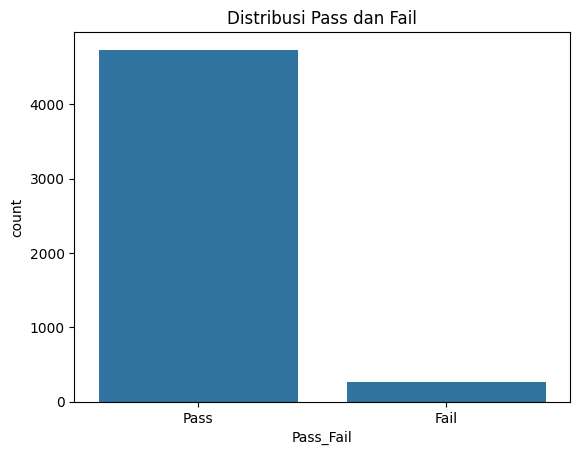

Pass_Fail
Pass    4735
Fail     265
Name: count, dtype: int64
Pass_Fail
Pass    94.7
Fail     5.3
Name: proportion, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Pass_Fail')
plt.title('Distribusi Pass dan Fail')
plt.show()

print(df['Pass_Fail'].value_counts())
print(df['Pass_Fail'].value_counts(normalize=True)*100)

# 2. Distribusi Performance Level

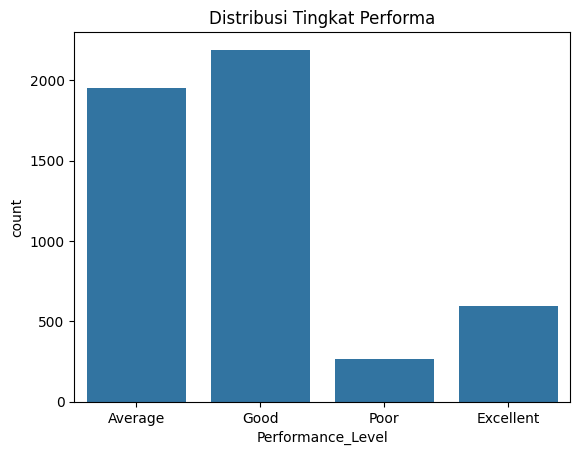

In [9]:
sns.countplot(data=df, x='Performance_Level')
plt.title('Distribusi Tingkat Performa')
plt.show()

# 3. Analisis Variabel Numerik

Variabel numerik

In [10]:
numerical_cols = [
    'Age',
    'Study_Hours_Per_Day',
    'Attendance_Percentage',
    'Math_Score',
    'Science_Score',
    'English_Score',
    'Previous_Year_Score',
    'Final_Percentage'
]

Histogram

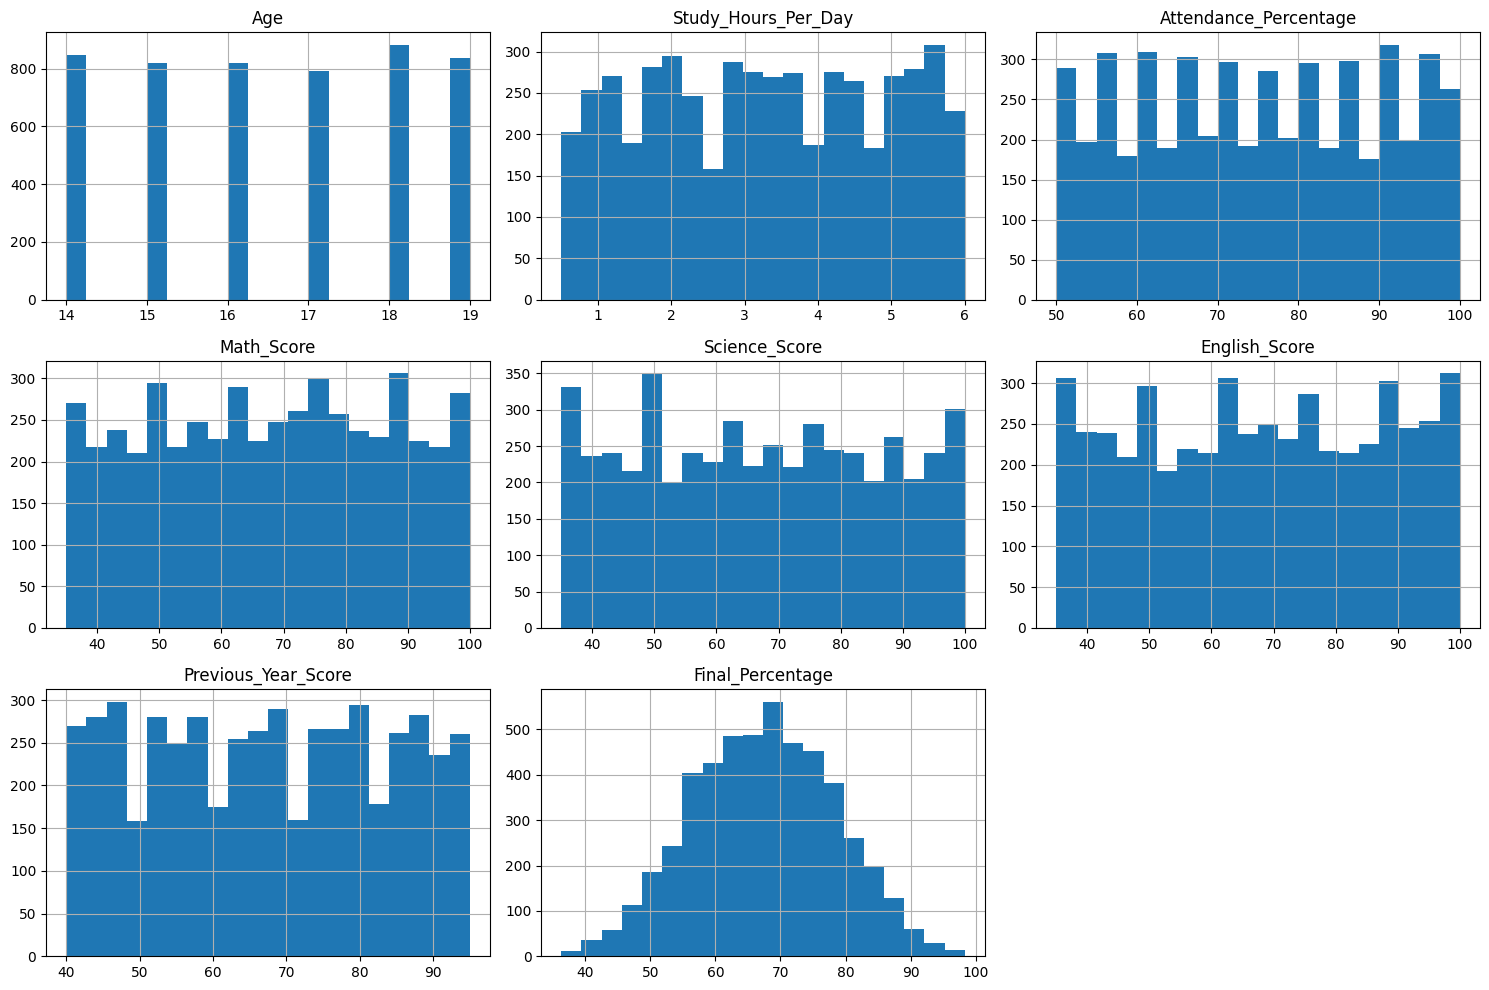

In [11]:
df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)
plt.tight_layout()
plt.show()

# 4. Korelasi Antar Variabel

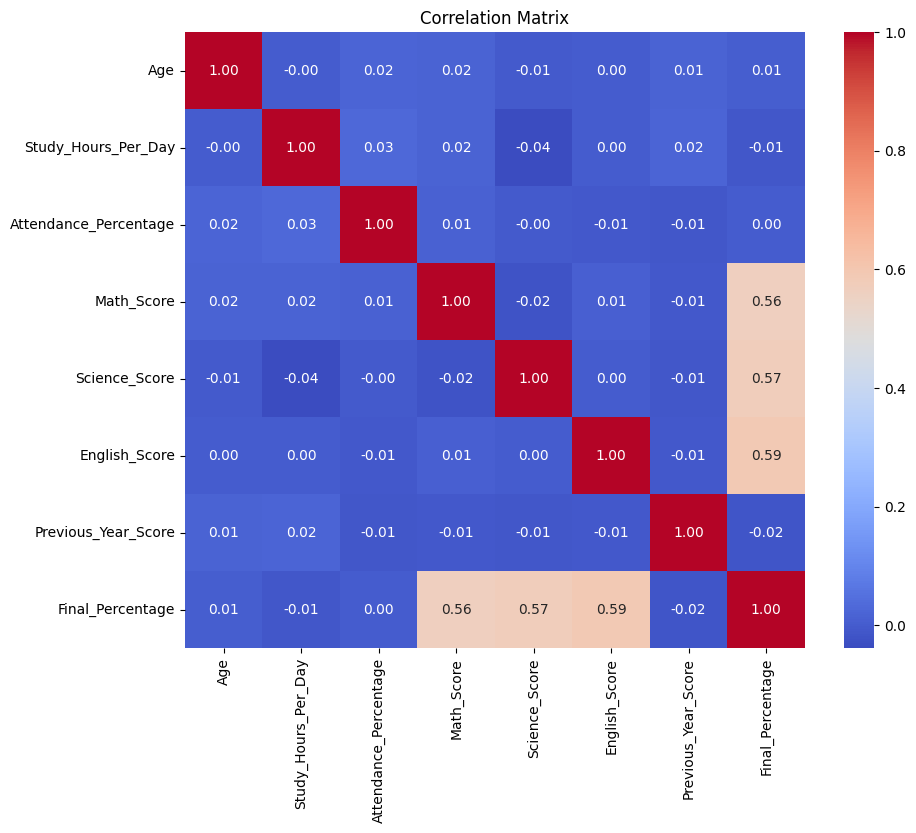

In [12]:
plt.figure(figsize=(10,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# 5. Pass vs Fail

Study Hours

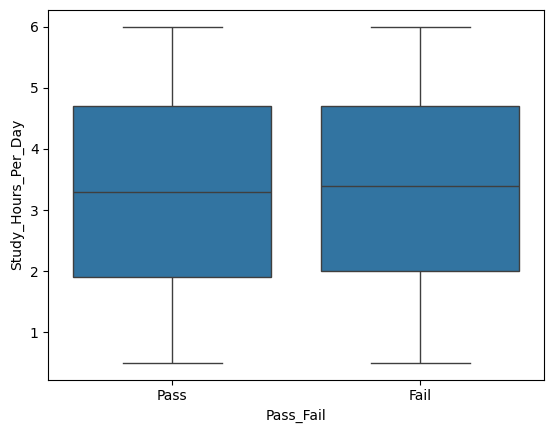

In [13]:
sns.boxplot(
    data=df,
    x='Pass_Fail',
    y='Study_Hours_Per_Day'
)
plt.show()

Attendance

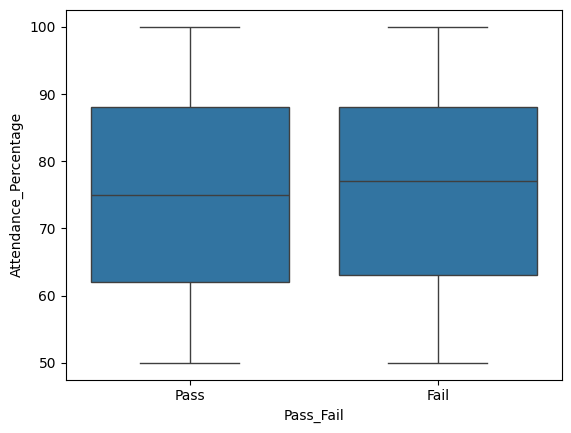

In [14]:
sns.boxplot(
    data=df,
    x='Pass_Fail',
    y='Attendance_Percentage'
)
plt.show()

Final Percentage

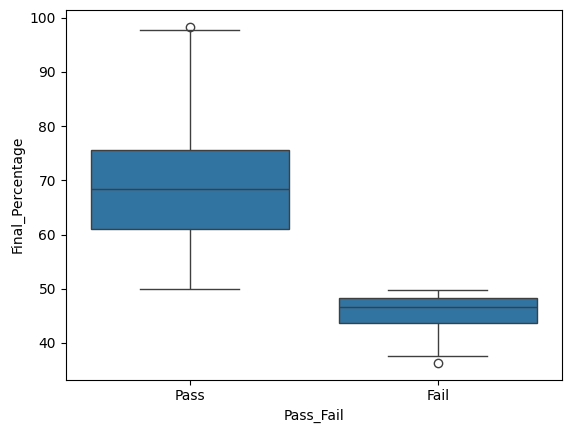

In [15]:
sns.boxplot(
    data=df,
    x='Pass_Fail',
    y='Final_Percentage'
)
plt.show()

# 6. Variabel Kategorikal

Data Kategorikal

In [16]:
categorical_cols = [
    'Gender',
    'Parental_Education',
    'Internet_Access',
    'Extracurricular_Activities'
]

Internet_Access

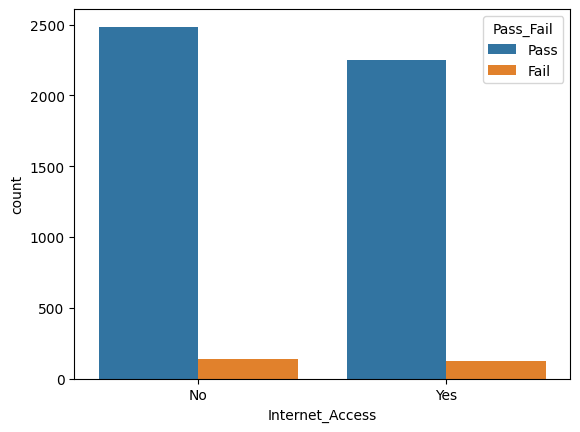

In [17]:
sns.countplot(
    data=df,
    x='Internet_Access',
    hue='Pass_Fail'
)
plt.show()

Gender

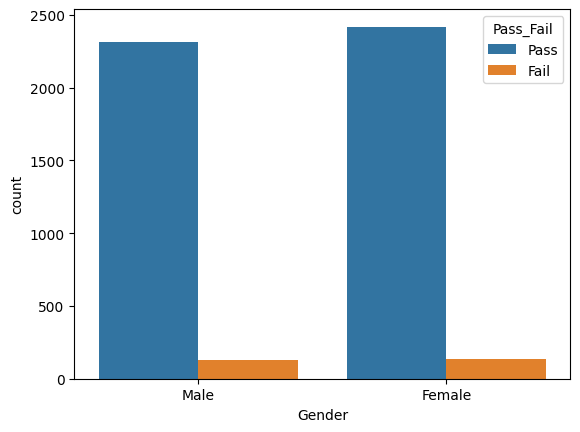

In [18]:
sns.countplot(
    data=df,
    x='Gender',
    hue='Pass_Fail'
)
plt.show()

Parental_Education

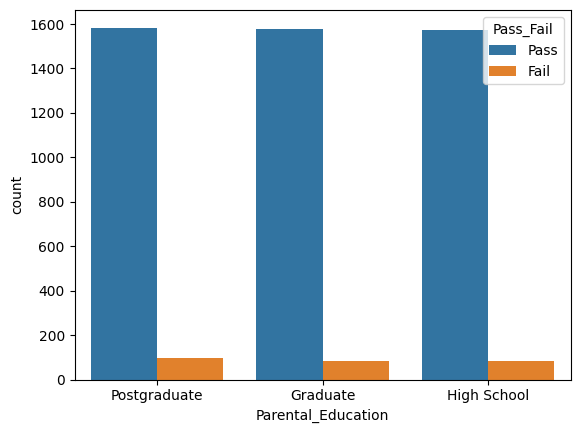

In [19]:
sns.countplot(
    data=df,
    x='Parental_Education',
    hue='Pass_Fail'
)
plt.show()

Extracurricular_Activities

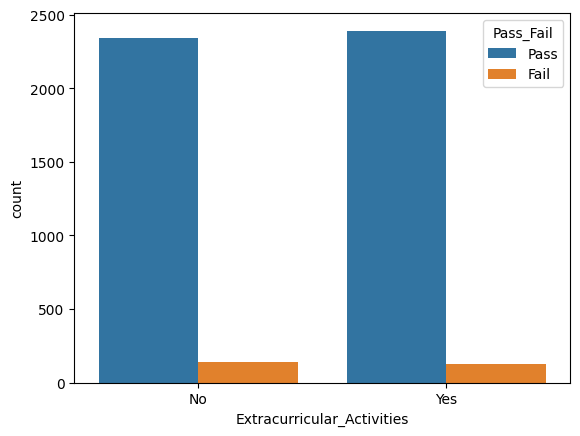

In [20]:
sns.countplot(
    data=df,
    x='Extracurricular_Activities',
    hue='Pass_Fail'
)
plt.show()

## **Data Preparation**

# 1. Hapus kolom Student_ID

In [21]:
df = df.drop('Student_ID', axis=1)

# 2. Encoding fitur kategorikal

In [22]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Performance_Level', 'Pass_Fail'],
      dtype='object')

# 3. label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Parental_Education',
    'Internet_Access',
    'Extracurricular_Activities',
    'Performance_Level',
    'Pass_Fail'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,15,1,12,1.0,65,2,0,0,40,39,72,81,50.33,0,1
1,19,0,9,1.6,58,0,0,1,80,44,35,47,53.00,0,1
2,14,0,12,3.6,64,1,1,1,83,73,59,58,71.67,2,1
3,18,0,9,5.5,68,2,1,0,68,48,77,54,64.33,0,1
4,14,1,10,5.0,80,1,1,0,41,46,36,68,41.00,3,0


# 4. Feature selection

In [24]:
X = df.drop(['Pass_Fail', 'Performance_Level'], axis=1)
y = df['Pass_Fail']

In [25]:
print(X.columns)

Index(['Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage'],
      dtype='object')


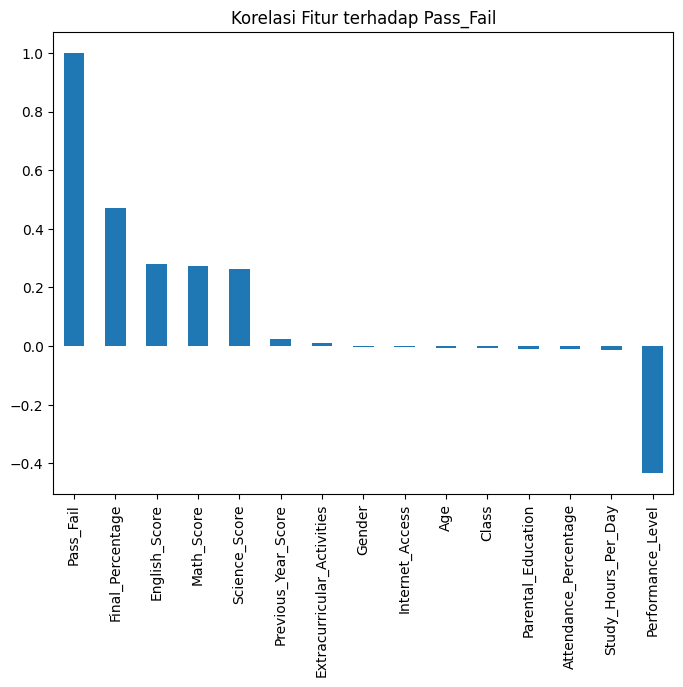

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_target = df.corr()['Pass_Fail'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_target.plot(kind='bar')
plt.title('Korelasi Fitur terhadap Pass_Fail')
plt.show()

Standardscaler

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# **K-Means Clustering**

Import library yang diperlukan

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Elbow Method

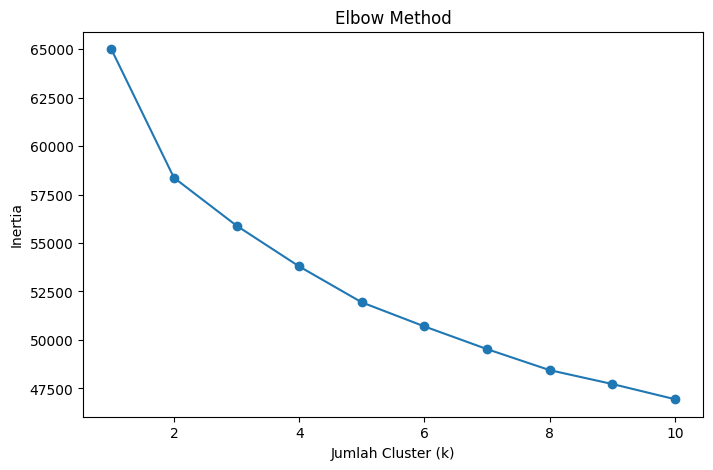

[64999.99999999998, 58368.71943695926, 55894.75470715032, 53792.18205875688, 51938.33032839083, 50696.690299738126, 49525.44011932839, 48441.42604365322, 47725.27412062685, 46941.31194804227]


In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
print(inertia)

Silhouette Score

In [30]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f'k={k}, Silhouette Score={score:.4f}')

k=2, Silhouette Score=0.0947
k=3, Silhouette Score=0.0670
k=4, Silhouette Score=0.0635
k=5, Silhouette Score=0.0656
k=6, Silhouette Score=0.0631
k=7, Silhouette Score=0.0690
k=8, Silhouette Score=0.0706
k=9, Silhouette Score=0.0666
k=10, Silhouette Score=0.0667


Training K-Means

In [31]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

Analisis tiap cluster

In [32]:
df['Cluster'].value_counts()

df.groupby('Cluster').mean(numeric_only=True)

,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
Cluster,,,,,,,,,,,,,,,
0,16.518077,0.500993,10.454509,3.280493,74.887167,1.003973,0.473977,0.520461,76.492650,75.379420,77.154152,67.199444,76.342034,1.764402,1.000000
1,16.499396,0.477648,10.538864,3.294120,74.952880,1.003222,0.477245,0.486911,58.897302,58.295207,58.283125,67.366089,58.491897,0.535240,0.893274


# **Logistic Regression**

Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 13)
X_test : (1000, 13)
y_train: (4000,)
y_test : (1000,)


Training

In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

Evaluation

In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        60
           1       1.00      1.00      1.00       940

    accuracy                           1.00      1000
   macro avg       1.00      0.97      0.99      1000
weighted avg       1.00      1.00      1.00      1000



# **Naive Bayes**

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

Training

In [37]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

Evaluation

In [38]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.987
              precision    recall  f1-score   support

           0       0.83      0.98      0.90        60
           1       1.00      0.99      0.99       940

    accuracy                           0.99      1000
   macro avg       0.91      0.99      0.95      1000
weighted avg       0.99      0.99      0.99      1000



In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        60
           1       1.00      0.99      0.99       940

    accuracy                           0.99      1000
   macro avg       0.91      0.99      0.95      1000
weighted avg       0.99      0.99      0.99      1000



**Perbaningan Model**

In [40]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [1.0, 1.0]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,Naive Bayes,1.0


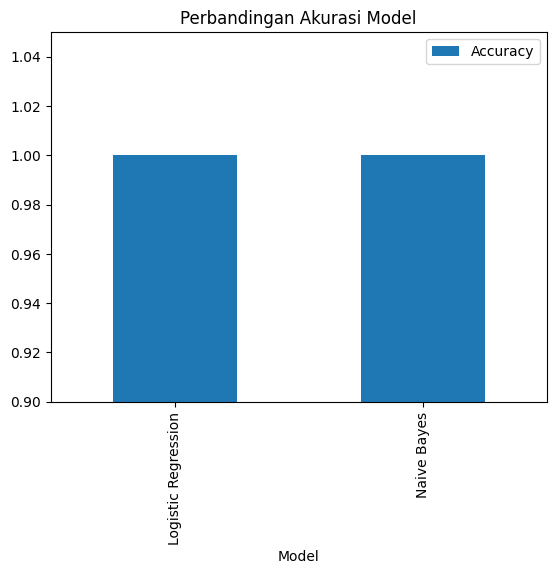

In [41]:
import matplotlib.pyplot as plt

comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Perbandingan Akurasi Model')
plt.ylim(0.9, 1.05)
plt.show()

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [43]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

In [44]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [lr_accuracy, nb_accuracy],
    'Precision': [lr_precision, nb_precision],
    'Recall': [lr_recall, nb_recall],
    'F1 Score': [lr_f1, nb_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.997,0.996819,1.000000,0.998407
1,Naive Bayes,0.987,0.998924,0.987234,0.993044


# **3. Deployment**

Lakukan save model Naive Bayes

In [45]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [46]:
joblib.dump(lr_model, 'model.pkl')

['model.pkl']

Instalasi pyngrok

In [47]:
!pip install pyngrok


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ACER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Konfigurasikan token

Contoh: !ngrok config add-authtoken token_kamu

In [48]:
!ngrok config add-authtoken 3DlFMj3q1u7zPaNNCWMjokdUvTJ_5SFCWmYEgH9qqkXk2Ma1A

Authtoken saved to configuration file: C:\Users\ACER\AppData\Local\ngrok\ngrok.yml


Instalasi Streamlit

In [49]:
!pip install streamlit


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ACER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [50]:
%%writefile app.py



import streamlit as st

import pandas as pd

import joblib



# =========================

# CONFIG

# =========================



st.set_page_config(

    page_title="Student Performance Prediction",

    page_icon="🎓",

    layout="wide"

)



# =========================

# LOAD MODEL

# =========================



model = joblib.load("model.pkl")

scaler = joblib.load("scaler.pkl")



# =========================

# HEADER

# =========================



st.title("🎓 Student Performance Prediction")



st.markdown("""

### Academic Performance Dashboard



Aplikasi ini memprediksi kemungkinan seorang siswa **PASS** atau **FAIL**

berdasarkan data akademik dan aktivitas belajar menggunakan

**Naive Bayes Classifier**.

""")



st.divider()



# =========================

# INPUT

# =========================



col1, col2 = st.columns(2)



with col1:



    st.subheader("👤 Informasi Siswa")



    age = st.selectbox(

        "Age",

        range(14, 20)

    )



    gender_text = st.selectbox(

        "Gender",

        ["Female", "Male"]

    )



    gender = 0 if gender_text == "Female" else 1



    student_class = st.selectbox(

        "Class",

        [9, 10, 11, 12]

    )



    parent_text = st.selectbox(

        "Parental Education",

        ["High School", "Bachelor", "Master"]

    )



    mapping_parent = {

        "High School": 0,

        "Bachelor": 1,

        "Master": 2

    }



    parental_education = mapping_parent[parent_text]



    internet_text = st.selectbox(

        "Internet Access",

        ["No", "Yes"]

    )



    internet_access = 1 if internet_text == "Yes" else 0



    extra_text = st.selectbox(

        "Extracurricular Activities",

        ["No", "Yes"]

    )



    extracurricular = 1 if extra_text == "Yes" else 0



with col2:



    st.subheader("📚 Data Akademik")



    study_hours = st.slider(

        "Study Hours Per Day",

        min_value=0.0,

        max_value=12.0,

        value=3.0,

        step=0.5

    )



    attendance = st.slider(

        "Attendance Percentage",

        min_value=0,

        max_value=100,

        value=75

    )



    math_score = st.slider(

        "Math Score",

        0,

        100,

        70

    )



    science_score = st.slider(

        "Science Score",

        0,

        100,

        70

    )



    english_score = st.slider(

        "English Score",

        0,

        100,

        70

    )



    previous_year_score = st.slider(

        "Previous Year Score",

        0,

        100,

        70

    )



    final_percentage = st.slider(

        "Final Percentage",

        0.0,

        100.0,

        70.0

    )



st.divider()



# =========================

# PREDICT

# =========================



if st.button("🔍 Predict Performance", use_container_width=True):



    data = pd.DataFrame({

        'Age':[age],

        'Gender':[gender],

        'Class':[student_class],

        'Study_Hours_Per_Day':[study_hours],

        'Attendance_Percentage':[attendance],

        'Parental_Education':[parental_education],

        'Internet_Access':[internet_access],

        'Extracurricular_Activities':[extracurricular],

        'Math_Score':[math_score],

        'Science_Score':[science_score],

        'English_Score':[english_score],

        'Previous_Year_Score':[previous_year_score],

        'Final_Percentage':[final_percentage]

    })



    data_scaled = scaler.transform(data)



    prediction = model.predict(data_scaled)[0]



    probabilities = model.predict_proba(data_scaled)



    fail_prob = probabilities[0][0] * 100

    pass_prob = probabilities[0][1] * 100



    st.divider()



    st.subheader("📊 Prediction Result")



    if prediction == 1:



        st.success("🎓 Student is Predicted to PASS")



        st.metric(

            "PASS Probability",

            f"{pass_prob:.2f}%"

        )



        st.progress(int(pass_prob))



        st.balloons()



    else:



        st.error("❌ Student is Predicted to FAIL")



        st.metric(

            "FAIL Probability",

            f"{fail_prob:.2f}%"

        )



        st.progress(int(fail_prob))



        st.snow()



    # =========================

    # SUMMARY

    # =========================



    st.divider()



    st.subheader("📋 Student Academic Summary")



    average_score = (

        math_score +

        science_score +

        english_score

    ) / 3



    m1, m2, m3 = st.columns(3)



    m1.metric(

        "Average Score",

        f"{average_score:.1f}"

    )



    m2.metric(

        "Attendance",

        f"{attendance}%"

    )



    m3.metric(

        "Study Hours",

        f"{study_hours} hrs/day"

    )



    st.write("### 🔎 Insights")



    # Study Hours



    if study_hours < 2:

        st.warning("📖 Study duration is relatively low.")

    elif study_hours < 5:

        st.info("📖 Study duration is adequate.")

    else:

        st.success("📖 Study duration is high.")



    # Attendance



    if attendance < 60:

        st.warning("📅 Attendance level is low.")

    elif attendance < 80:

        st.info("📅 Attendance level is moderate.")

    else:

        st.success("📅 Attendance level is high.")



    # Average Score



    if average_score < 60:

        st.warning("📝 Academic performance is below average.")

    elif average_score < 80:

        st.info("📝 Academic performance is good.")

    else:

        st.success("📝 Academic performance is excellent.")



    # Internet



    if internet_access == 1:

        st.success("🌐 Student has internet access.")

    else:

        st.warning("🌐 Student does not have internet access.")



    # Extracurricular



    if extracurricular == 1:

        st.success("🏆 Student participates in extracurricular activities.")

    else:

        st.info("🏆 Student does not participate in extracurricular activities.")



    st.divider()



    st.subheader("📄 Input Data")



    st.dataframe(

        data,

        use_container_width=True

    )



st.caption(

    "Built using Naive Bayes Classifier for Student Performance Prediction."

)

Overwriting app.py


In [51]:
from pyngrok import ngrok
import threading
import os

ngrok.kill()

def run_streamlit():
  os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit)
thread.start()

public_url = ngrok.connect(addr='8501')
print(public_url)

t=2026-06-11T12:57:25+0700 lvl=eror msg="unable to evaluate ngrok agent binary path for symlinks" obj=tunnels.session err="GetFileAttributesEx C:\\Users\\ACER\\AppData\\Local\\ngrok\\ngrok.exe: The system cannot find the file specified."


NgrokTunnel: "https://pedigree-bagpipe-varmint.ngrok-free.dev" -> "http://localhost:8501"
